# Introducción al Procesamiento Digital de Imágenes

**Material desarrollado para el IFTS 24 - 2026**

**Espacio:** Laboratorio de Tecnologías de la Imagen Digital

---

## Objetivo

En este cuaderno vamos a dar el primer paso del laboratorio: entender que una imagen digital no es algo misterioso, sino una estructura de datos que podemos cargar, mirar, medir y transformar con Python.

## Al terminar este material van a poder:

1. Explicar qué representa una imagen digital dentro de una computadora.
2. Cargar imágenes de ejemplo usando `scikit-image`.
3. Visualizar imágenes con `matplotlib`.
4. Reconocer la diferencia entre una imagen RGB y una imagen en escala de grises.
5. Inspeccionar dimensiones, canales y valores de píxeles usando NumPy.
6. Aplicar transformaciones básicas como espejado vertical y horizontal.

## Microglosario

Antes de escribir código, acordemos algunas palabras que van a aparecer todo el tiempo.

| Término | Significado en lenguaje llano |
|---|---|
| Imagen digital | Una grilla de puntos. Cada punto guarda información de color o intensidad. |
| Píxel | Cada casillero mínimo de esa grilla. Es la unidad básica de una imagen. |
| Canal | Una capa de información de color. En RGB tenemos rojo, verde y azul. |
| Array | Una estructura de datos ordenada. En imágenes, suele ser una matriz o un bloque de matrices. |
| Escala de grises | Una imagen donde cada píxel guarda un solo valor de intensidad, de oscuro a claro. |
| RGB | Modelo de color que combina tres canales: rojo, verde y azul. |

## Una imagen como una planilla

Para empezar, pensemos una imagen como si fuera una planilla de cálculo.

Cada celda de la planilla sería un píxel. Si la imagen está en escala de grises, cada celda guarda un número: más chico significa más oscuro, más grande significa más claro.

Si la imagen está en color, cada celda guarda tres números: cuánto rojo, cuánto verde y cuánto azul tiene ese punto.

Esa idea es clave: cuando procesamos imágenes, no estamos "tocando fotos" de forma mágica. Estamos operando sobre números organizados.

## 1. Cargamos las librerías

Primero importamos las herramientas que vamos a usar.

`NumPy` nos permite trabajar con arrays. `matplotlib` nos permite mostrar imágenes. `scikit-image` nos da imágenes de ejemplo y funciones útiles para procesamiento digital.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data
from skimage import color

print("✓ Librerías cargadas correctamente.")

✓ Librerías cargadas correctamente.


## 2. Cargamos una imagen de ejemplo

Vamos a usar una imagen incluida en `scikit-image`. Esto nos evita depender de archivos externos durante la primera práctica.

La imagen funciona como una muestra de laboratorio: siempre está disponible y nos permite concentrarnos en entender el procedimiento.

In [2]:
imagen_color = data.rocket()

print("✓ Imagen cargada correctamente.")
print("Tipo de dato:", type(imagen_color))

✓ Imagen cargada correctamente.
Tipo de dato: <class 'numpy.ndarray'>


## 3. Mostramos la imagen

Una imagen guardada como array no se ve automáticamente. Para verla, necesitamos pedirle a Python que la dibuje.

Vamos a crear una función pequeña para visualizar imágenes. Una función es como una receta: le damos ingredientes, en este caso una imagen y un título, y repite siempre los mismos pasos para mostrar el resultado.

In [3]:
def mostrar_imagen(imagen, titulo="Imagen", mapa_color=None):
    plt.figure(figsize=(7, 5))
    plt.imshow(imagen, cmap=mapa_color)
    plt.title(titulo)
    plt.axis("off")
    plt.show()

print("✓ Función mostrar_imagen creada correctamente.")

✓ Función mostrar_imagen creada correctamente.


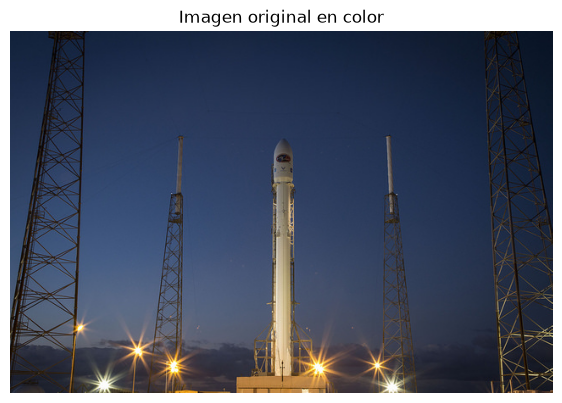

In [4]:
mostrar_imagen(imagen_color, "Imagen original en color")

### Para pensar

- ¿Qué tipo de información visual aparece en esta imagen?
- ¿Qué partes podrían ser fáciles o difíciles de detectar automáticamente?
- Si tuviéramos que describir esta imagen solo con números, ¿qué necesitaríamos guardar?

## 4. Inspeccionamos la forma de la imagen

La propiedad `shape` nos dice cómo está organizada la imagen.

Podemos pensarla como las medidas de una caja: alto, ancho y profundidad. En una imagen RGB, la profundidad son los tres canales de color.

In [5]:
forma_imagen = imagen_color.shape

alto = forma_imagen[0]
ancho = forma_imagen[1]
canales = forma_imagen[2]

print("✓ Dimensiones de la imagen")
print("Alto en píxeles:", alto)
print("Ancho en píxeles:", ancho)
print("Cantidad de canales:", canales)

✓ Dimensiones de la imagen
Alto en píxeles: 427
Ancho en píxeles: 640
Cantidad de canales: 3


### Para pensar

- ¿Por qué una imagen en color necesita tres canales?
- ¿Qué creen que pasaría con la forma de la imagen si fuera blanco y negro?

## 5. Miramos un píxel puntual

Un píxel de una imagen RGB guarda tres valores. Esos valores indican la intensidad de rojo, verde y azul.

Es parecido a mezclar pintura con tres perillas: una perilla controla cuánto rojo agregamos, otra cuánto verde y otra cuánto azul.

In [6]:
fila_pixel = 100
columna_pixel = 200

pixel_elegido = imagen_color[fila_pixel, columna_pixel]

valor_rojo = pixel_elegido[0]
valor_verde = pixel_elegido[1]
valor_azul = pixel_elegido[2]

print("✓ Valores del píxel seleccionado")
print("Fila:", fila_pixel)
print("Columna:", columna_pixel)
print("Rojo:", valor_rojo)
print("Verde:", valor_verde)
print("Azul:", valor_azul)

✓ Valores del píxel seleccionado
Fila: 100
Columna: 200
Rojo: 43
Verde: 57
Azul: 92


### Para pensar

- ¿Cuál de los tres canales tiene el valor más alto en este píxel?
- Mirando la imagen original, ¿ese resultado tiene sentido para la zona seleccionada?

## 6. Separamos los canales RGB

Ahora vamos a separar la imagen en sus tres capas: rojo, verde y azul.

La analogía de las transparencias ayuda: imaginemos tres láminas apiladas. Cada lámina muestra cuánto aporta un color. Al juntarlas, aparece la imagen completa.

In [7]:
canal_rojo = imagen_color[:, :, 0]
canal_verde = imagen_color[:, :, 1]
canal_azul = imagen_color[:, :, 2]

print("✓ Canales separados correctamente.")
print("Forma del canal rojo:", canal_rojo.shape)
print("Forma del canal verde:", canal_verde.shape)
print("Forma del canal azul:", canal_azul.shape)

✓ Canales separados correctamente.
Forma del canal rojo: (427, 640)
Forma del canal verde: (427, 640)
Forma del canal azul: (427, 640)


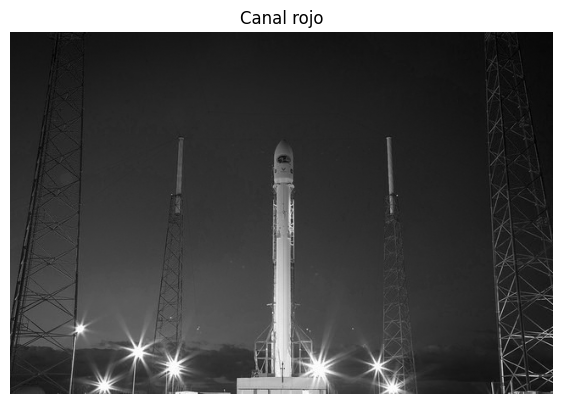

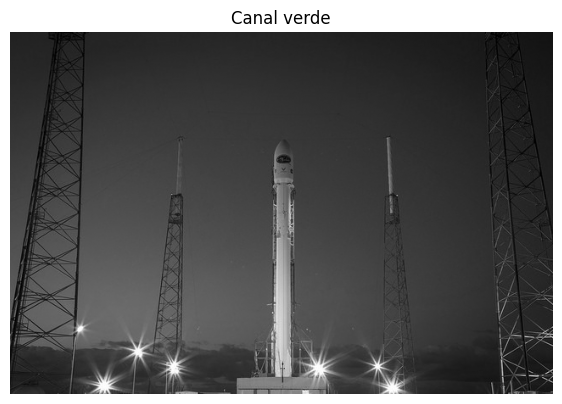

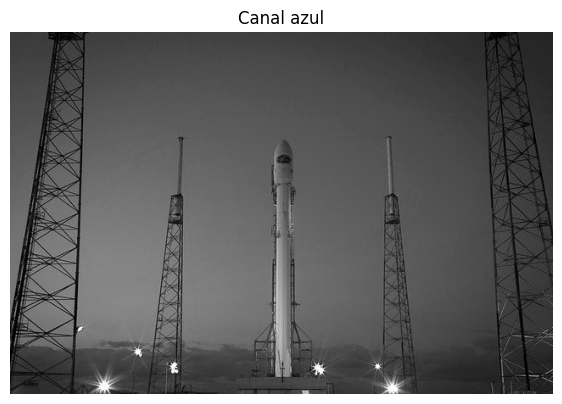

In [8]:
mostrar_imagen(canal_rojo, "Canal rojo", mapa_color="gray")
mostrar_imagen(canal_verde, "Canal verde", mapa_color="gray")
mostrar_imagen(canal_azul, "Canal azul", mapa_color="gray")

### Para pensar

- ¿En qué canal se ven con más claridad las zonas claras del cohete?
- ¿Qué canal parece aportar más información en el fondo?
- ¿Por qué mostramos cada canal con un mapa de color gris?

## 7. Convertimos la imagen a escala de grises

Una imagen en escala de grises guarda una sola intensidad por píxel.

Podemos pensarlo como pasar de una receta con tres ingredientes de color a una sola medida de luminosidad. Se pierde información cromática, pero a veces se gana simplicidad para analizar formas, bordes o regiones.

In [9]:
imagen_gris = color.rgb2gray(imagen_color)

print("✓ Imagen convertida a escala de grises.")
print("Forma de la imagen original:", imagen_color.shape)
print("Forma de la imagen en gris:", imagen_gris.shape)

✓ Imagen convertida a escala de grises.
Forma de la imagen original: (427, 640, 3)
Forma de la imagen en gris: (427, 640)


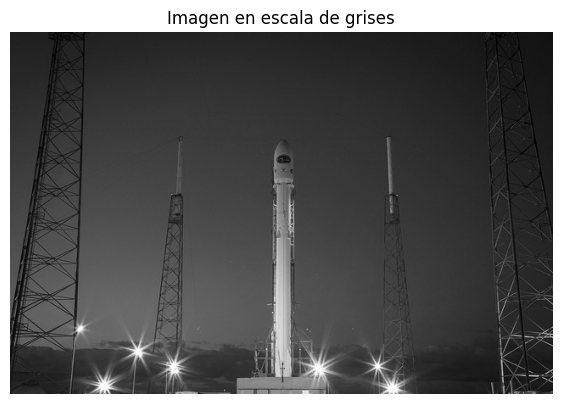

In [10]:
mostrar_imagen(imagen_gris, "Imagen en escala de grises", mapa_color="gray")

### Para pensar

- ¿Qué información desapareció al convertir la imagen a escala de grises?
- ¿Qué información todavía podemos analizar?
- ¿Para qué tareas podría alcanzar con una imagen en gris?

## 8. Consultamos el tamaño total

La propiedad `size` cuenta cuántos valores numéricos hay guardados en el array.

En una imagen RGB, cada píxel aporta tres valores. Por eso el tamaño total no coincide solo con alto por ancho: también cuenta los canales.

In [11]:
tamano_total_color = imagen_color.size
tamano_total_gris = imagen_gris.size

print("✓ Tamaños calculados")
print("Valores guardados en la imagen RGB:", tamano_total_color)
print("Valores guardados en la imagen en gris:", tamano_total_gris)

✓ Tamaños calculados
Valores guardados en la imagen RGB: 819840
Valores guardados en la imagen en gris: 273280


### Para pensar

- ¿Por qué la imagen RGB guarda más valores que la imagen en gris?
- ¿Qué impacto puede tener esto en memoria o velocidad de procesamiento?

## 9. Espejamos la imagen

Una transformación básica es invertir el orden de las filas o de las columnas.

Si invertimos las filas, la imagen queda dada vuelta verticalmente. Si invertimos las columnas, queda espejada horizontalmente. Es como cambiar el orden de las hojas o de las columnas en una planilla.

In [12]:
imagen_invertida_vertical = np.flipud(imagen_color)
imagen_invertida_horizontal = np.fliplr(imagen_color)

print("✓ Transformaciones aplicadas correctamente.")

✓ Transformaciones aplicadas correctamente.


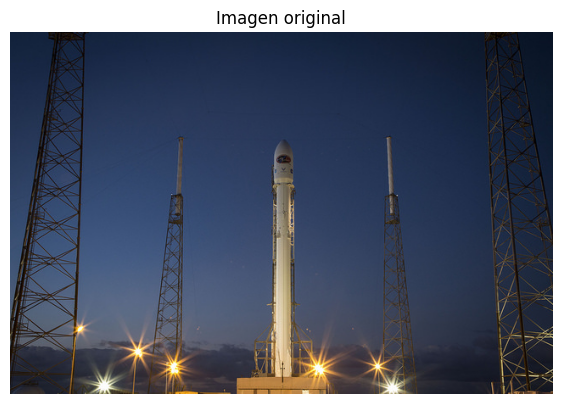

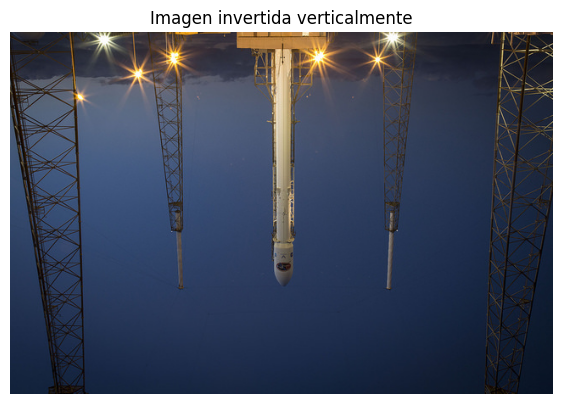

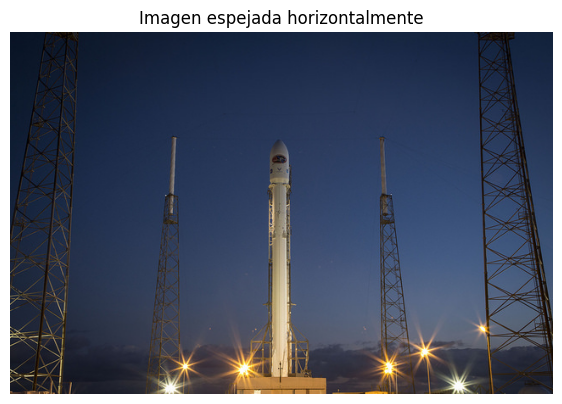

In [13]:
mostrar_imagen(imagen_color, "Imagen original")
mostrar_imagen(imagen_invertida_vertical, "Imagen invertida verticalmente")
mostrar_imagen(imagen_invertida_horizontal, "Imagen espejada horizontalmente")

### Para pensar

- ¿Qué operación modificó el eje vertical?
- ¿Qué operación modificó el eje horizontal?
- ¿Cambiaron los colores de la imagen o solo cambió la posición de los píxeles?

## 10. Mini producción de cierre

Para cerrar el primer cuaderno, vamos a producir una comparación visual simple.

La idea es construir una figura con cuatro vistas de la misma imagen: original, gris, invertida verticalmente y espejada horizontalmente. Esta figura puede servir como primera evidencia de laboratorio.

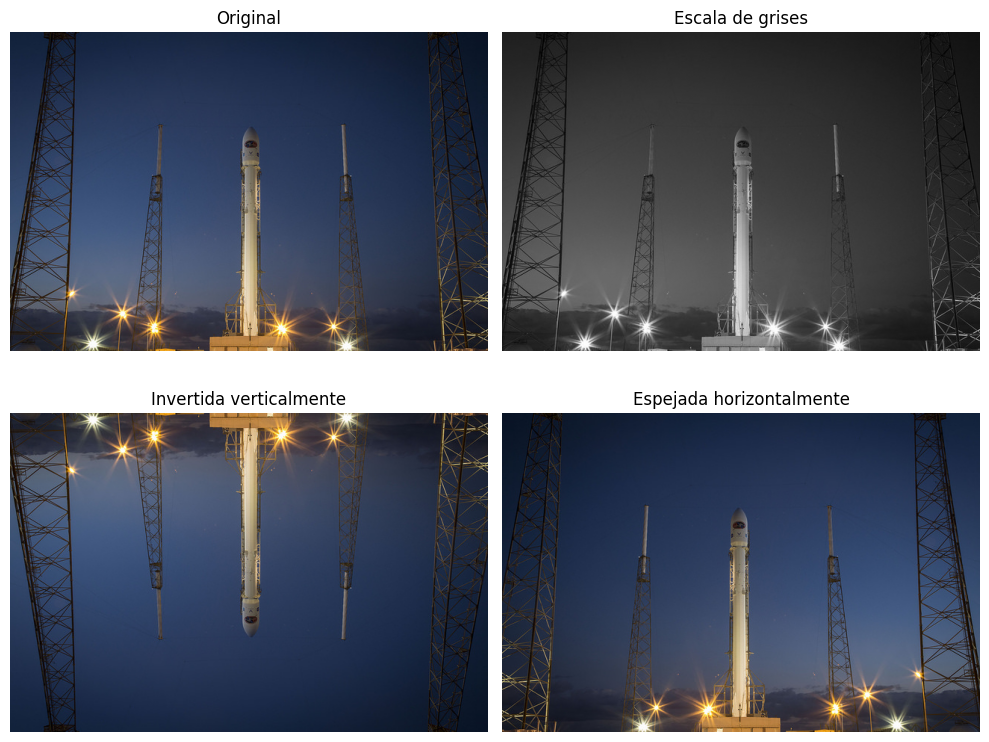

✓ Comparación visual generada correctamente.


In [14]:
figura, ejes = plt.subplots(2, 2, figsize=(10, 8))

# Primera fila
axes_fila_1 = ejes[0]
eje_original = axes_fila_1[0]
eje_gris = axes_fila_1[1]

# Segunda fila
axes_fila_2 = ejes[1]
eje_vertical = axes_fila_2[0]
eje_horizontal = axes_fila_2[1]

eje_original.imshow(imagen_color)
eje_original.set_title("Original")
eje_original.axis("off")

eje_gris.imshow(imagen_gris, cmap="gray")
eje_gris.set_title("Escala de grises")
eje_gris.axis("off")

eje_vertical.imshow(imagen_invertida_vertical)
eje_vertical.set_title("Invertida verticalmente")
eje_vertical.axis("off")

eje_horizontal.imshow(imagen_invertida_horizontal)
eje_horizontal.set_title("Espejada horizontalmente")
eje_horizontal.axis("off")

plt.tight_layout()
plt.show()

print("✓ Comparación visual generada correctamente.")

## Actividad breve

Elijan una imagen de ejemplo distinta de `scikit-image` y repitan el flujo principal:

1. Cargar la imagen.
2. Mostrarla.
3. Consultar su `shape` y su `size`.
4. Convertirla a escala de grises si corresponde.
5. Separar sus canales si es RGB.
6. Aplicar una inversión vertical u horizontal.
7. Escribir tres observaciones sobre lo que cambió y lo que no cambió.

Pueden explorar algunas imágenes disponibles con:

In [15]:
imagenes_disponibles = [
    "astronaut",
    "camera",
    "cat",
    "coffee",
    "coins",
    "chelsea",
    "rocket",
]

print("Imágenes sugeridas para explorar:")

for nombre_imagen in imagenes_disponibles:
    print("-", nombre_imagen)

Imágenes sugeridas para explorar:
- astronaut
- camera
- cat
- coffee
- coins
- chelsea
- rocket


## Cierre

En este cuaderno vimos la idea base del procesamiento digital de imágenes: una imagen puede representarse como números organizados.

Eso nos permite medirla, separarla en canales, convertirla a escala de grises y modificar la posición de sus píxeles. En el próximo cuaderno vamos a usar esa misma idea para analizar histogramas y empezar a separar regiones de una imagen mediante umbralización.